# LASSA SEROPREVALENCE MACHINE LEARNING
## SECTION 7: VISUAL EXPLANATIONS FOR SECTION 6 MODEL

**Goal:** Generate plots that help explain the Section 6 model:
- How PCR probabilities are distributed (train vs test)
- How calibration behaves
- How threshold choice affects F1/precision/recall
- How cross-reactivity probability relates to PCR probability
- Confusion matrix visualization for test set
- (Optional) simple global feature importance from one XGBoost model

This notebook **only visualizes**; it does **not change** the model.


---
## CELL 7.0: IMPORTS + LOAD SECTION 6 ARTIFACTS


In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.calibration import calibration_curve

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 7),
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

Path("results/plots").mkdir(parents=True, exist_ok=True)

print("Loading Section 6 artifacts...")

preprocess = joblib.load("models/section6_preprocess_drop.joblib")
ensemble_models = joblib.load("models/section6_xgb_ensemble.joblib")
platt = joblib.load("models/section6_platt_calibrator.joblib")
cross_artifacts = joblib.load("models/section6_cross_reactivity_model.joblib")

with open("results/reports/section6_inference_config.json", "r") as f:
    config = json.load(f)

best_threshold = float(config["best_threshold_calibrated"])
num_cols = config["columns"]["numeric"]
cat_cols = config["columns"]["categorical"]

igm_col = cross_artifacts["igm_col"]
igg_col = cross_artifacts["igg_col"]
igm_thr = cross_artifacts["igm_thr"]
igg_thr = cross_artifacts["igg_thr"]
cross_model = cross_artifacts["model"]

print("✓ Loaded all Section 6 artifacts")
print("Best calibrated threshold (train F1):", best_threshold)
print("IgM column:", igm_col)
print("IgG column:", igg_col)


Loading Section 6 artifacts...
✓ Loaded all Section 6 artifacts
Best calibrated threshold (train F1): 0.02436454849498328
IgM column: lab_results.IgM OD_Values 
IgG column: lab_results.IgG OD_Values


---
## CELL 7.1: RELOAD RAW DATA & REBUILD TRAIN/TEST SPLIT (SAME AS SECTION 6)

We re-create the same train/test split used in Section 6 so we can generate the same probabilities again.


In [2]:
# IMPORTANT: must match Section 6
DATA_PATH = "data/embeddings/data/LASV_Master_Data!.csv"
TARGET_COL = "lab_results.PCR_Results"
RANDOM_SEED = 42

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Missing dataset at: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()

df = df.drop(columns=["Full_Name", "Patient_ID"], errors="ignore")

mapping = {"No Kb (Negative)": 0, "320Kb (Positive)": 1}
y_all = df[TARGET_COL].map(mapping)
if y_all.isna().any():
    bad = df.loc[y_all.isna(), TARGET_COL].unique().tolist()
    raise ValueError(f"Unmapped target values found: {bad}")
y_all = y_all.astype(int).values
X_all = df.drop(columns=[TARGET_COL])

DROP_COLS = [c for c in ["Town/City", "Occupation"] if c in X_all.columns]
X_all = X_all.drop(columns=DROP_COLS, errors="ignore").copy()

print("Full X shape:", X_all.shape)
print("Positives:", int((y_all==1).sum()), "Negatives:", int((y_all==0).sum()))

from sklearn.model_selection import train_test_split

pos_idx = np.where(y_all == 1)[0]
neg_idx = np.where(y_all == 0)[0]

if len(pos_idx) != 3:
    raise ValueError(f"Expected exactly 3 positives, found {len(pos_idx)}")

test_pos_idx = np.array([pos_idx[0]])
train_pos_idx = np.array(pos_idx[1:])

X_neg = X_all.iloc[neg_idx]
y_neg = y_all[neg_idx]

X_neg_train, X_neg_test, y_neg_train, y_neg_test = train_test_split(
    X_neg, y_neg, test_size=0.2, random_state=RANDOM_SEED, stratify=y_neg
)

train_idx = np.concatenate([
    train_pos_idx,
    X_neg_train.index.values
])
test_idx = np.concatenate([
    test_pos_idx,
    X_neg_test.index.values
])

X_train = X_all.loc[train_idx].reset_index(drop=True)
y_train = y_all[train_idx]
X_test = X_all.loc[test_idx].reset_index(drop=True)
y_test = y_all[test_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positives:", int((y_train==1).sum()), "Train negatives:", int((y_train==0).sum()))
print("Test positives:", int((y_test==1).sum()), "Test negatives:", int((y_test==0).sum()))


Full X shape: (250, 41)
Positives: 3 Negatives: 247
Train shape: (199, 41) Test shape: (51, 41)
Train positives: 2 Train negatives: 197
Test positives: 1 Test negatives: 50


---
## CELL 7.2: Recompute RAW & CALIBRATED PROBABILITIES (Train & Test)


In [4]:
def ensemble_predict_proba(models, X):
    probs = [m.predict_proba(X)[:,1] for m in models]
    return np.mean(probs, axis=0)

Xt_train = preprocess.transform(X_train)
Xt_test = preprocess.transform(X_test)

train_proba_raw = ensemble_predict_proba(ensemble_models, Xt_train)
test_proba_raw = ensemble_predict_proba(ensemble_models, Xt_test)

train_proba_cal = platt.predict_proba(train_proba_raw.reshape(-1,1))[:,1]
test_proba_cal = platt.predict_proba(test_proba_raw.reshape(-1,1))[:,1]

print("Train raw PR-AUC:", average_precision_score(y_train, train_proba_raw))
print("Train cal PR-AUC:", average_precision_score(y_train, train_proba_cal))
print("Test raw PR-AUC:", average_precision_score(y_test, test_proba_raw))
print("Test cal PR-AUC:", average_precision_score(y_test, test_proba_cal))

print("Train raw ROC-AUC:", roc_auc_score(y_train, train_proba_raw))
print("Train cal ROC-AUC:", roc_auc_score(y_train, train_proba_cal))
print("Test raw ROC-AUC:", roc_auc_score(y_test, test_proba_raw))
print("Test cal ROC-AUC:", roc_auc_score(y_test, test_proba_cal))


Train raw PR-AUC: 1.0
Train cal PR-AUC: 1.0
Test raw PR-AUC: 0.125
Test cal PR-AUC: 0.125
Train raw ROC-AUC: 1.0
Train cal ROC-AUC: 1.0
Test raw ROC-AUC: 0.86
Test cal ROC-AUC: 0.86


---
## CELL 7.3: Plot Distribution of PCR Probabilities (Train vs Test)


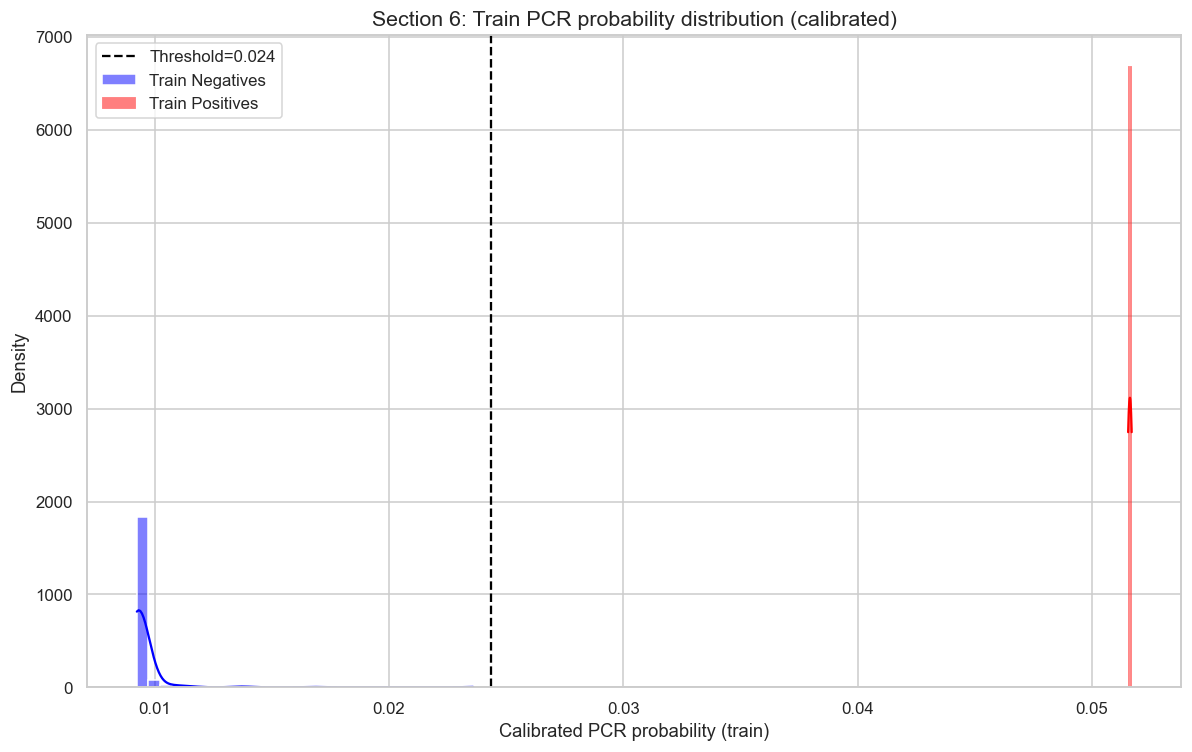

✓ Saved: results/plots/section7_train_pcr_probability_distribution.png


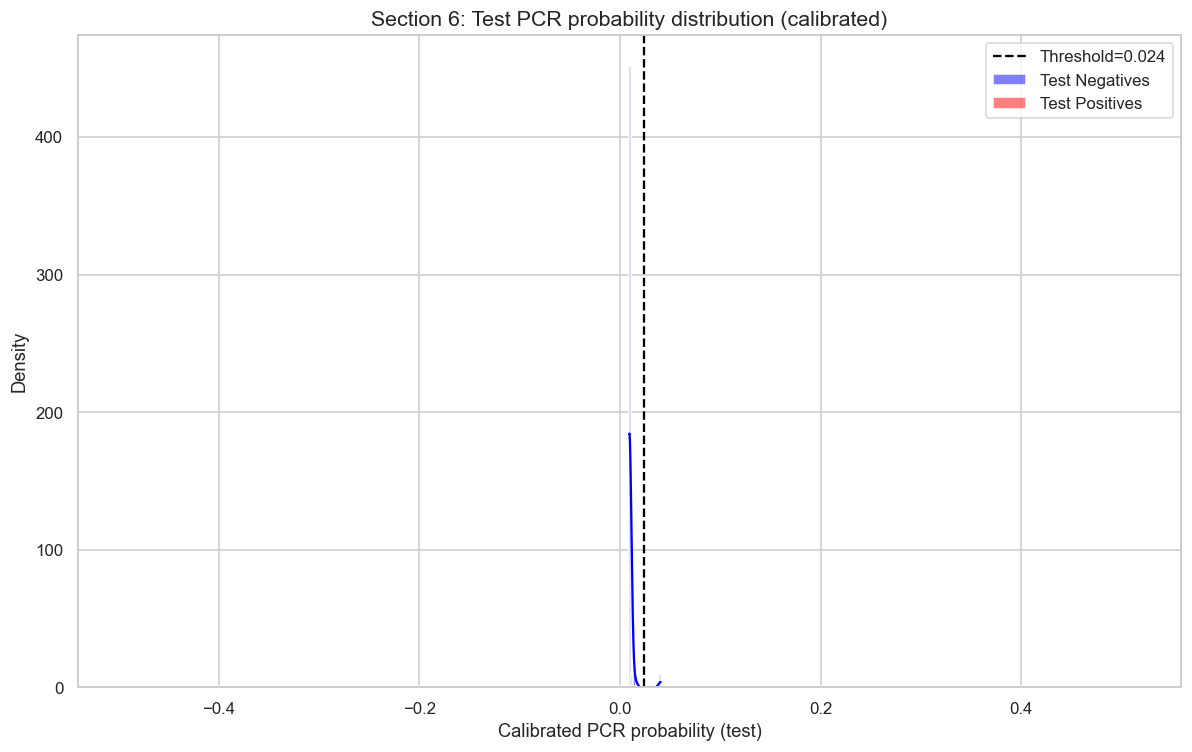

✓ Saved: results/plots/section7_test_pcr_probability_distribution.png


In [5]:
plt.figure()
sns.histplot(train_proba_cal[y_train==0], color="blue", label="Train Negatives", kde=True, stat="density", alpha=0.5)
sns.histplot(train_proba_cal[y_train==1], color="red", label="Train Positives", kde=True, stat="density", alpha=0.5)
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Threshold={best_threshold:.3f}")
plt.xlabel("Calibrated PCR probability (train)")
plt.ylabel("Density")
plt.title("Section 6: Train PCR probability distribution (calibrated)")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section7_train_pcr_probability_distribution.png")
plt.show()
print("✓ Saved: results/plots/section7_train_pcr_probability_distribution.png")

plt.figure()
sns.histplot(test_proba_cal[y_test==0], color="blue", label="Test Negatives", kde=True, stat="density", alpha=0.5)
sns.histplot(test_proba_cal[y_test==1], color="red", label="Test Positives", kde=True, stat="density", alpha=0.5)
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Threshold={best_threshold:.3f}")
plt.xlabel("Calibrated PCR probability (test)")
plt.ylabel("Density")
plt.title("Section 6: Test PCR probability distribution (calibrated)")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section7_test_pcr_probability_distribution.png")
plt.show()
print("✓ Saved: results/plots/section7_test_pcr_probability_distribution.png")


---
## CELL 7.4: Calibration Curve (Train + Test)

We show how well calibrated probabilities are, with the usual ‘perfect diagonal’ reference.


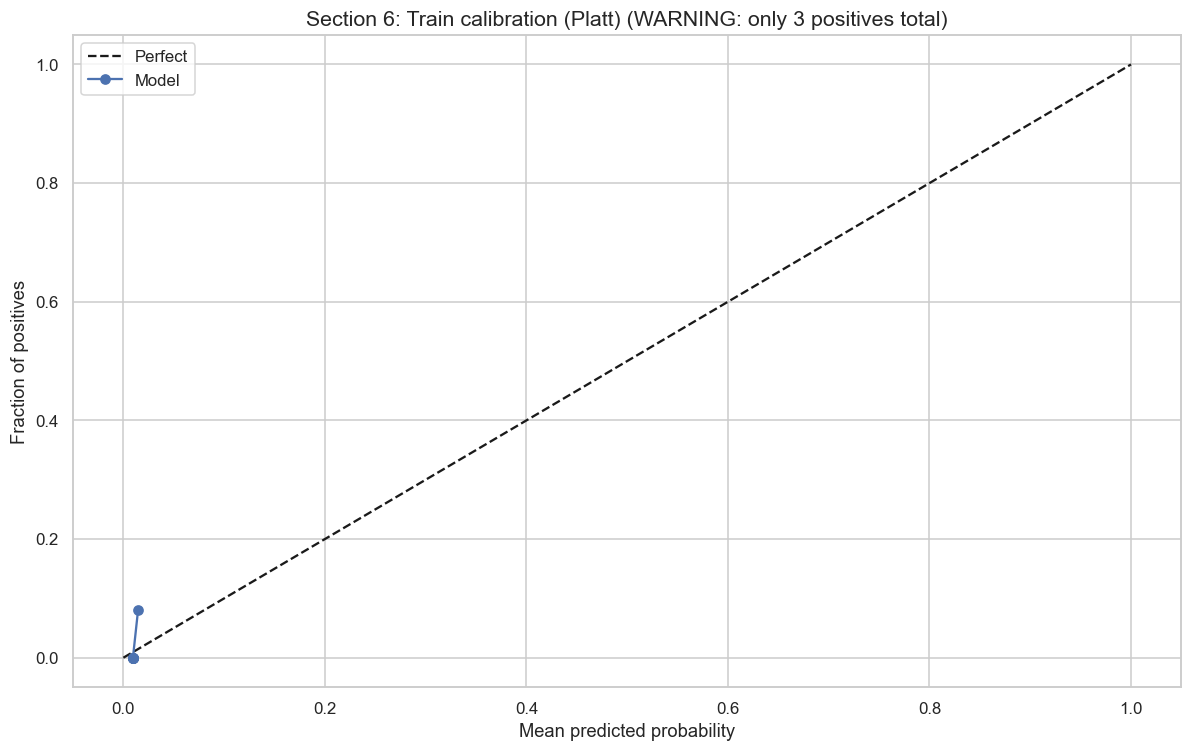

✓ Saved: results/plots/section7_train_calibration_curve.png


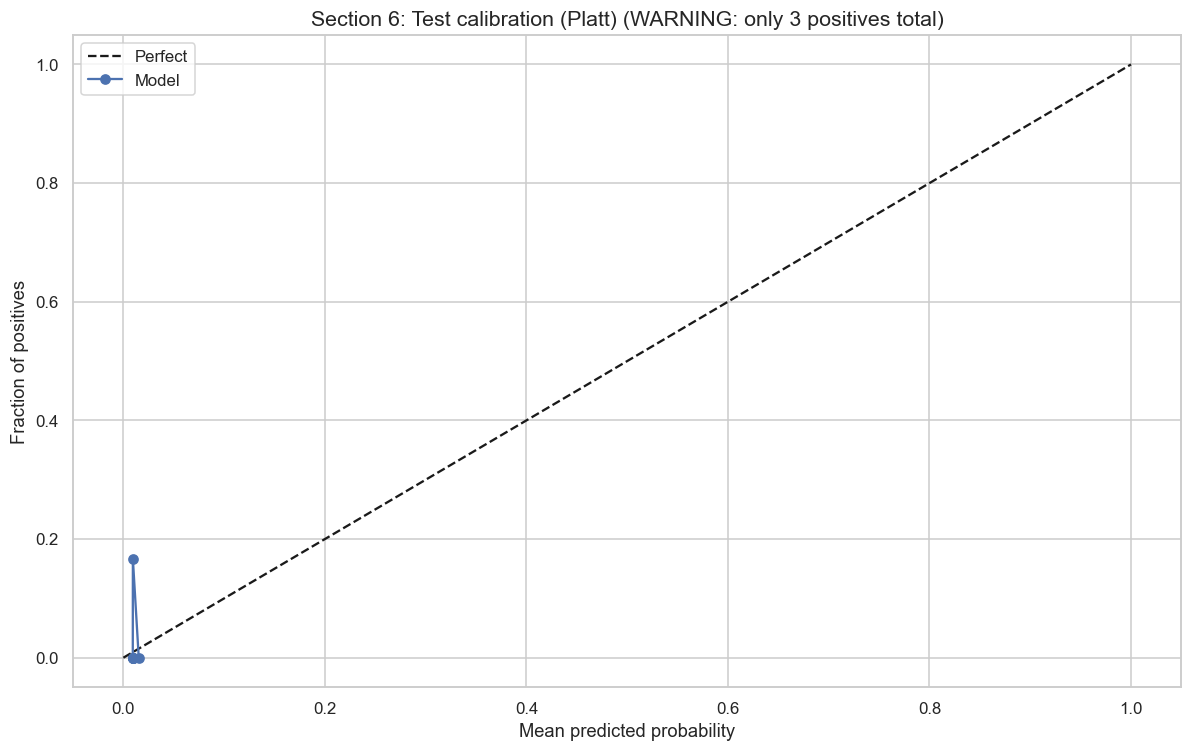

✓ Saved: results/plots/section7_test_calibration_curve.png


In [6]:
def plot_calibration(y_true, proba, title, filename, n_bins=8):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins, strategy="quantile")
    plt.figure()
    plt.plot([0,1],[0,1], "k--", label="Perfect")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title + " (WARNING: only 3 positives total)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f"✓ Saved: {filename}")

plot_calibration(y_train, train_proba_cal,
                 title="Section 6: Train calibration (Platt)",
                 filename="results/plots/section7_train_calibration_curve.png")

plot_calibration(y_test, test_proba_cal,
                 title="Section 6: Test calibration (Platt)",
                 filename="results/plots/section7_test_calibration_curve.png")


---
## CELL 7.5: Threshold Sweep Plot (Train, Calibrated)

Visualize how F1 / precision / recall change as we move the threshold.


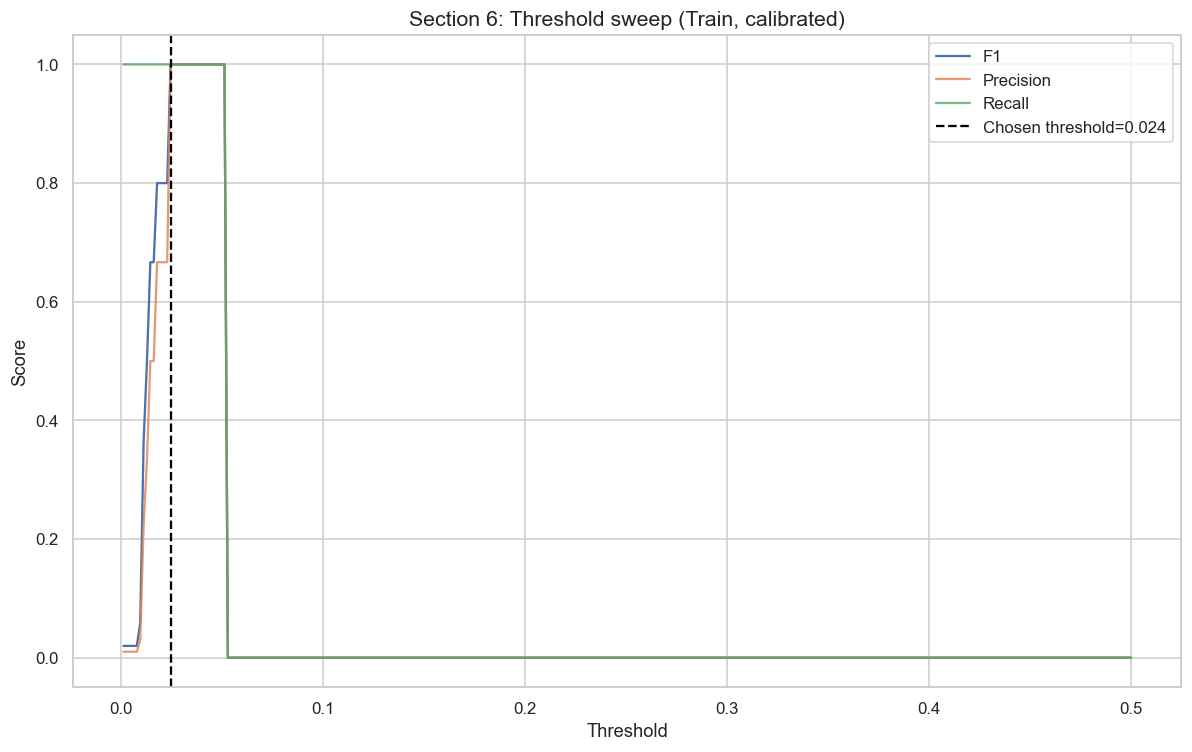

✓ Saved: results/plots/section7_train_threshold_sweep.png


In [7]:
thresholds = np.linspace(0.001, 0.5, 300)
rows = []
for t in thresholds:
    y_hat = (train_proba_cal >= t).astype(int)
    rows.append({
        "threshold": t,
        "f1": f1_score(y_train, y_hat, zero_division=0),
        "precision": precision_score(y_train, y_hat, zero_division=0),
        "recall": recall_score(y_train, y_hat, zero_division=0)
    })
ts_df = pd.DataFrame(rows)

plt.figure()
plt.plot(ts_df["threshold"], ts_df["f1"], label="F1")
plt.plot(ts_df["threshold"], ts_df["precision"], label="Precision", alpha=0.8)
plt.plot(ts_df["threshold"], ts_df["recall"], label="Recall", alpha=0.8)
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Chosen threshold={best_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Section 6: Threshold sweep (Train, calibrated)")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section7_train_threshold_sweep.png")
plt.show()
print("✓ Saved: results/plots/section7_train_threshold_sweep.png")


---
## CELL 7.6: Cross-Reactivity vs PCR Probability Scatter (Train & Test)

This helps explain the idea of:
- high `p_cross_reactive` but low `p_pcr_pos` → high cross-reactivity, PCR-negative pattern
- low `p_cross_reactive` but high `p_pcr_pos` → likely true PCR positive


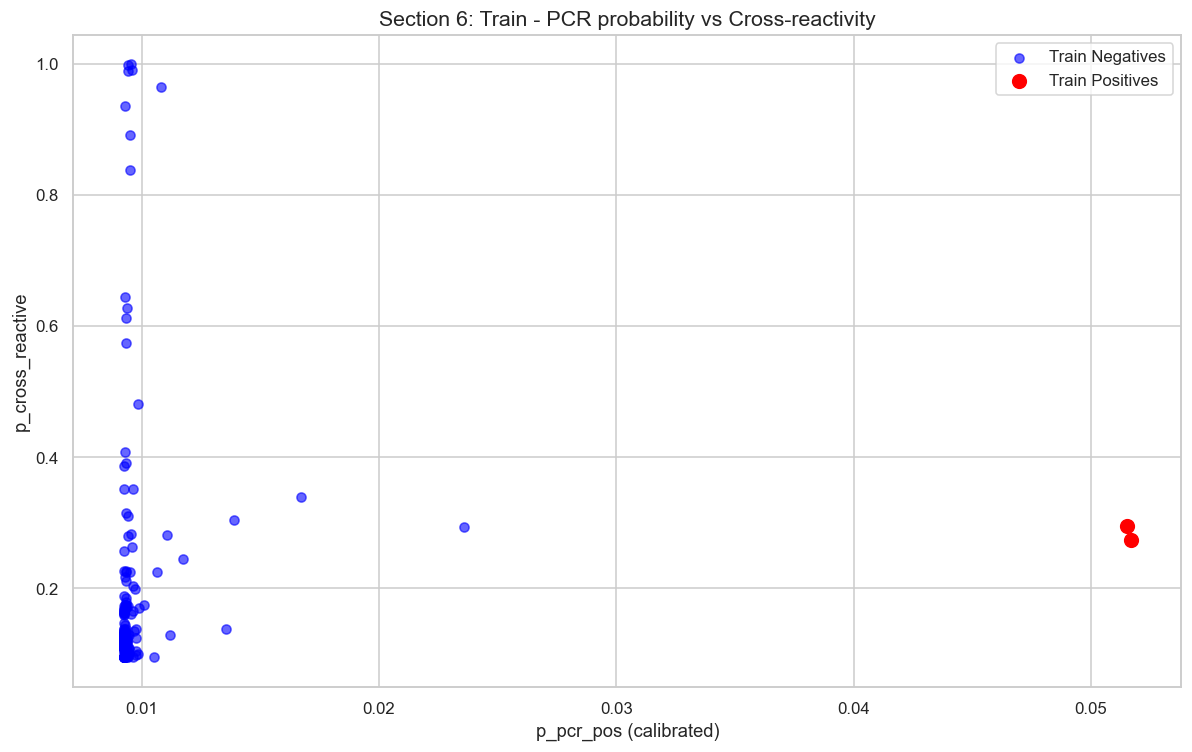

✓ Saved: results/plots/section7_train_pcr_vs_crossreactivity.png


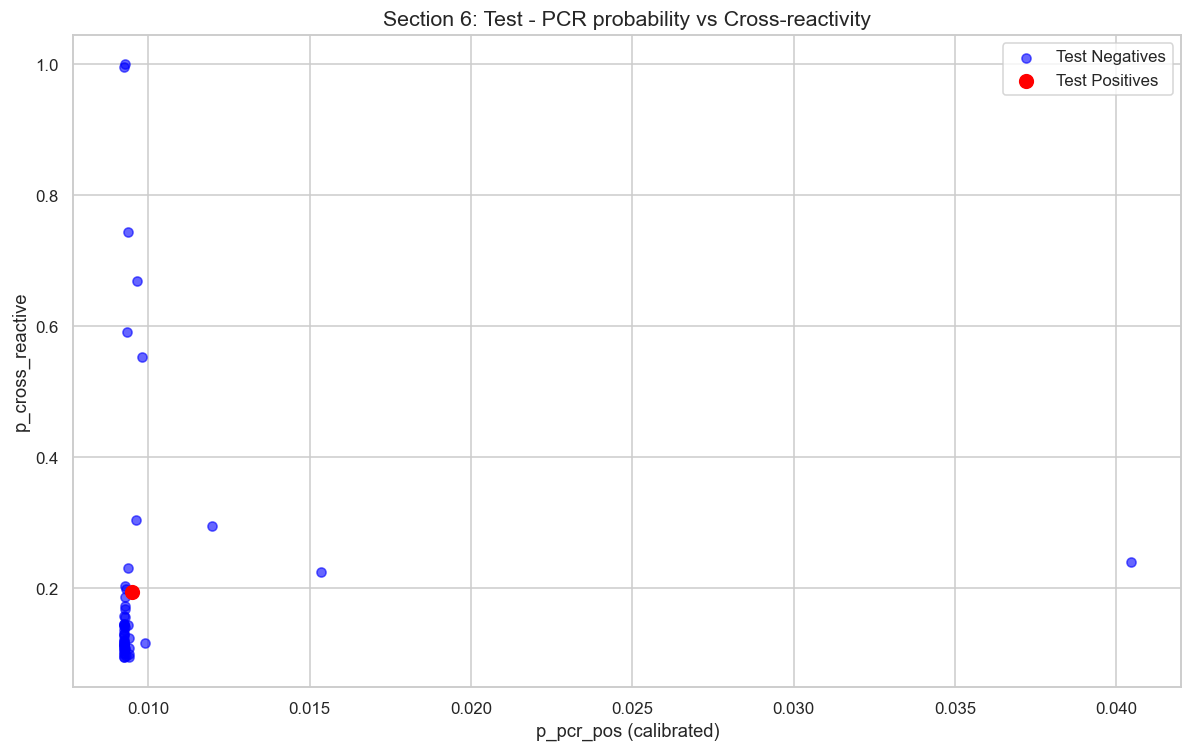

✓ Saved: results/plots/section7_test_pcr_vs_crossreactivity.png


In [8]:
# Compute cross-reactivity probabilities
X_train_od = X_train[[igm_col, igg_col]].values
X_test_od = X_test[[igm_col, igg_col]].values

p_cross_train = cross_model.predict_proba(X_train_od)[:,1]
p_cross_test = cross_model.predict_proba(X_test_od)[:,1]

plt.figure()
plt.scatter(train_proba_cal[y_train==0], p_cross_train[y_train==0],
            c="blue", alpha=0.6, label="Train Negatives")
plt.scatter(train_proba_cal[y_train==1], p_cross_train[y_train==1],
            c="red", s=80, label="Train Positives")
plt.xlabel("p_pcr_pos (calibrated)")
plt.ylabel("p_cross_reactive")
plt.title("Section 6: Train - PCR probability vs Cross-reactivity")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section7_train_pcr_vs_crossreactivity.png")
plt.show()
print("✓ Saved: results/plots/section7_train_pcr_vs_crossreactivity.png")

plt.figure()
plt.scatter(test_proba_cal[y_test==0], p_cross_test[y_test==0],
            c="blue", alpha=0.6, label="Test Negatives")
plt.scatter(test_proba_cal[y_test==1], p_cross_test[y_test==1],
            c="red", s=80, label="Test Positives")
plt.xlabel("p_pcr_pos (calibrated)")
plt.ylabel("p_cross_reactive")
plt.title("Section 6: Test - PCR probability vs Cross-reactivity")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section7_test_pcr_vs_crossreactivity.png")
plt.show()
print("✓ Saved: results/plots/section7_test_pcr_vs_crossreactivity.png")


---
## CELL 7.7: Confusion Matrix Heatmap (Test)


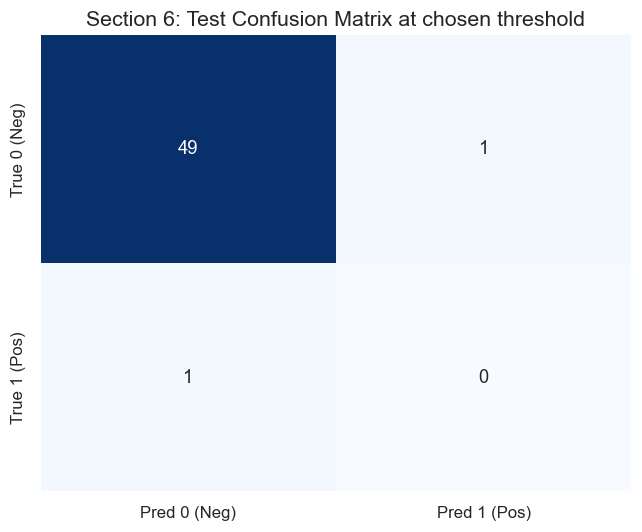

✓ Saved: results/plots/section7_test_confusion_matrix.png


In [9]:
y_test_hat = (test_proba_cal >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_test_hat)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0 (Neg)", "Pred 1 (Pos)"],
            yticklabels=["True 0 (Neg)", "True 1 (Pos)"])
plt.title("Section 6: Test Confusion Matrix at chosen threshold")
plt.tight_layout()
plt.savefig("results/plots/section7_test_confusion_matrix.png")
plt.show()
print("✓ Saved: results/plots/section7_test_confusion_matrix.png")


---
## CELL 7.8 (Optional): Simple Global Feature Importance from One XGBoost Model

This is **exploratory only**. With only 3 positives, importance is unstable.


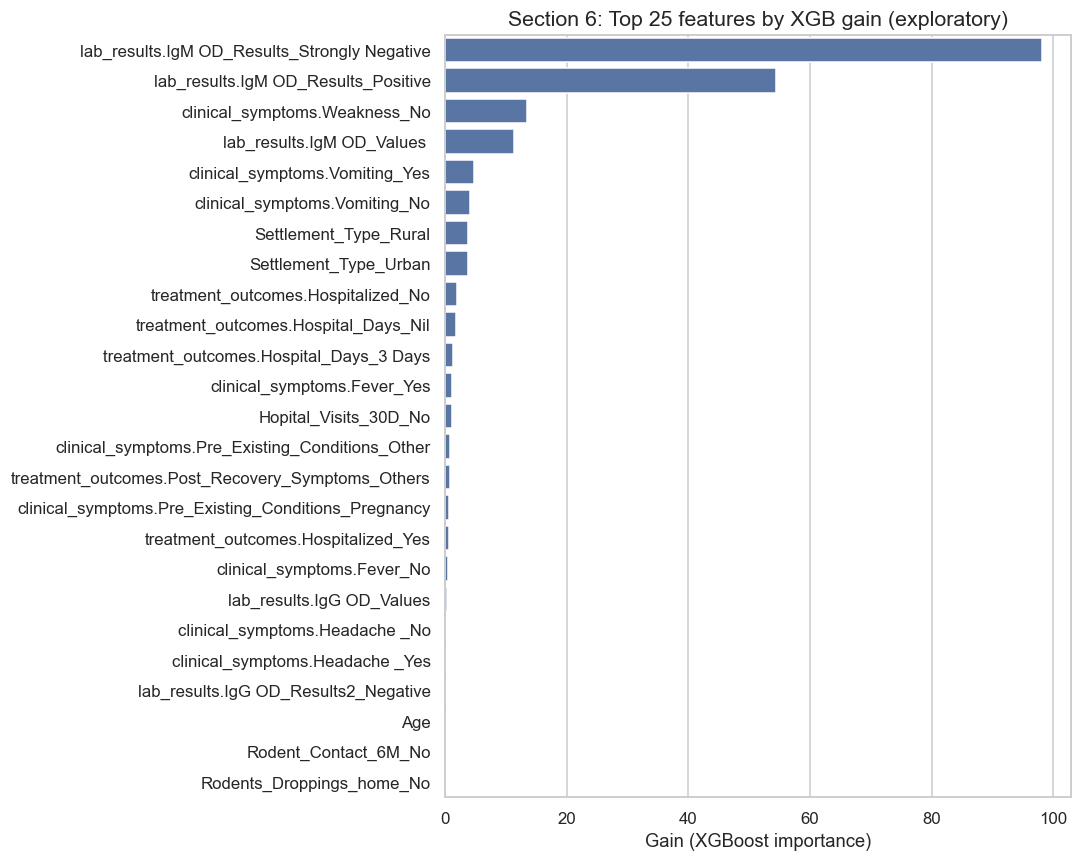

Top features (exploratory):


,feature,gain
25,lab_results.IgM OD_Results_Strongly Negative,98.106262
24,lab_results.IgM OD_Results_Positive,54.429928
14,clinical_symptoms.Weakness_No,13.447579
1,lab_results.IgM OD_Values,11.262834
16,clinical_symptoms.Vomiting_Yes,4.759291
15,clinical_symptoms.Vomiting_No,4.045611
3,Settlement_Type_Rural,3.793201
4,Settlement_Type_Urban,3.739084
19,treatment_outcomes.Hospitalized_No,1.895270
22,treatment_outcomes.Hospital_Days_Nil,1.736398


✓ Saved: results/plots/section7_feature_importance_gain.png


In [10]:
one_model = ensemble_models[0]

feature_names = preprocess.get_feature_names_out()
booster = one_model.get_booster()
score_dict = booster.get_score(importance_type="gain")

rows = []
for fname, gain in score_dict.items():
    try:
        idx = int(fname.replace("f", ""))
        real_name = feature_names[idx]
    except Exception:
        real_name = fname
    rows.append({"feature": real_name, "gain": float(gain)})

imp_df = pd.DataFrame(rows).sort_values("gain", ascending=False)

top_n = 25
top_imp = imp_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_imp, x="gain", y="feature", orient="h")
plt.xlabel("Gain (XGBoost importance)")
plt.ylabel("")
plt.title(f"Section 6: Top {top_n} features by XGB gain (exploratory)")
plt.tight_layout()
plt.savefig("results/plots/section7_feature_importance_gain.png")
plt.show()

print("Top features (exploratory):")
display(top_imp)
top_imp.to_csv("results/reports/section7_feature_importance_gain.csv", index=False)
print("✓ Saved: results/plots/section7_feature_importance_gain.png")
